In [46]:
# Load required packages
using DelimitedFiles
using LinearAlgebra
using Plots
using Plots.PlotMeasures
using Revise
# using Revise
gr()

# Add JPEC to path and load
push!(LOAD_PATH, joinpath(@__DIR__, ".."))
using JPEC

# Initialize globals with proper grid parameters
# The kernel function expects coordinates on a regular theta grid
mth = 512  # Number of poloidal grid points
inputs = JPEC.VacuumMod.VacuumInput(
    mtheta=mth,
    n=1,
)
settings = JPEC.VacuumMod.WallGeometry()
shapings = JPEC.VacuumMod.WallShapeSettings(leqarcw = 0)


JPEC.VacuumMod.WallShapeSettings(:conformal, 0.05, 1.5, 0.0, 0.5, 0.05, 1.2, 1.0, 0.0, 0, 500, 1.0e-5)

# Make virtual plasma boundary

In [47]:
using Plots

# 1. Grid setup
mth = inputs.mtheta
theta = range(0, 1, length=mth+1)[1:mth] 
dtheta_val = 2π / mth

# 2. Physical parameters
R0 = 6.0          
a = 2.0           
kappa = 2.0       
delta_tri = 0.6   # This 'delta' is the actual Triangularity for the D-shape
n = 1             
qa = 4.3          

# 3. Coordinate and derivative calculations with Triangularity (D-shape)
alpha = 2π .* theta
x = R0 .+ a .* cos.(alpha .+ asin(delta_tri) .* sin.(alpha))
z = kappa .* a .* sin.(alpha)

# Derivatives (Chain rule applied)
common_slope = 2π .* (1 .+ asin(delta_tri) .* cos.(alpha))
dx_dtheta = -a .* sin.(alpha .+ asin(delta_tri) .* sin.(alpha)) .* common_slope
dz_dtheta = 2π .* kappa .* a .* cos.(alpha)

# 4. Phase offset 'delta' (Set to 0 as it's a coordinate phase, not triangularity)
delta_vec = zeros(mth) # Now 0-filled, delta_param removed
cnqd = cos.(n * qa .* delta_vec) # will be 1.0
snqd = sin.(n * qa .* delta_vec) # will be 0.0

# 5. Mode setup
mlow, mhigh = -10, 10
l_modes = mlow:mhigh
mpert = length(l_modes)

# 6. Basis function matrices calculation
sinlt = zeros(mth, mpert)
coslt = zeros(mth, mpert)
snlth = zeros(mth, mpert)
cslth = zeros(mth, mpert)

for (j, l) in enumerate(l_modes)
    angle_pure = 2π * l .* theta
    # Since delta_vec is 0, angle_with_delta == angle_pure
    angle_with_delta = angle_pure .+ (n * qa .* delta_vec)
    
    sinlt[:, j] = sin.(angle_pure)
    coslt[:, j] = cos.(angle_pure)
    snlth[:, j] = sin.(angle_with_delta)
    cslth[:, j] = cos.(angle_with_delta)
end

# 7. Construct PlasmaGeometry
plasma = JPEC.VacuumMod.PlasmaGeometry(
    x = x,
    z = z,
    delta = delta_vec,
    dx_dtheta = dx_dtheta,
    dz_dtheta = dz_dtheta,
    cnqd = cnqd,
    snqd = snqd,
    sinlt = sinlt,
    coslt = coslt,
    snlth = snlth,
    cslth = cslth
)

println("Plasma Geometry setup complete with Triangularity δ = $delta_tri")

Plasma Geometry setup complete with Triangularity δ = 0.6


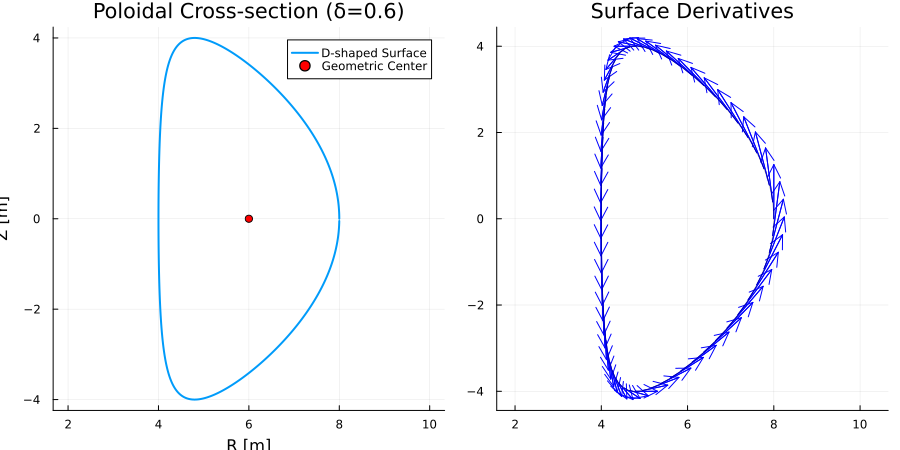

In [48]:
# --- Visualization ---

# Plot 1: Poloidal Cross-section (Showing the D-shape)
p1 = plot(x, z, label="D-shaped Surface", lw=2, aspect_ratio=:equal,
          title="Poloidal Cross-section (δ=$delta_tri)",
          xlabel="R [m]", ylabel="Z [m]")
scatter!([R0], [0], label="Geometric Center", color=:red)

# Plot 2: Tangent Vectors
step = 8
p2 = quiver(x[1:step:end], z[1:step:end], 
            quiver=(dx_dtheta[1:step:end].*0.05, dz_dtheta[1:step:end].*0.05),
            label="Tangent Vectors", color=:blue)
plot!(x, z, label="", color=:black, alpha=0.3, aspect_ratio=:equal)
title!(p2, "Surface Derivatives")

plot(p1, p2, layout=(1, 2), size=(900, 450))

# Various wall options 

### Error control for various options

If you try other wall shapings or have typing errors in the wall shape, the error occurs like below

In [49]:
# This is correct
shapings.shape = :conformal

:conformal

In [50]:
# This is wrong (🌽 ) - Korean Joke
shapings.shape = :cornfarmer 

ArgumentError: ArgumentError: Invalid shape: :cornfarmer. Must be one of [:conformal, :elliptical, :dee, :mod_dee, :from_file]

In [52]:
if shapings.leqarcw==1
    println("wall points will be in same distance")
else
    println("wall points will be in different distance")
end

wall points will be in different distance


Here, we can just put leqarcw as 1

In [53]:
shapings.leqarcw = 1

1

## Conformal option

In [54]:
shapings.shape = :conformal
shapings.a = 0.2
xwall, zwall, _ = JPEC.VacuumMod.wwall(inputs, shapings, plasma);

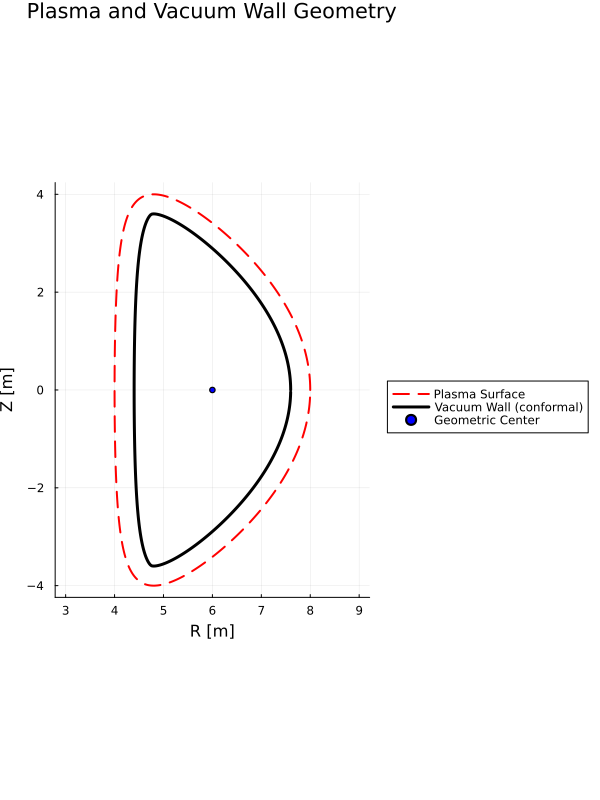

In [55]:
# 1. Plot settings
p = plot(aspect_ratio=:equal, size=(600, 800), legend=:outerright)

# 2. Plot Plasma Surface (Inner curve)
plot!(p, plasma.x, plasma.z, label="Plasma Surface", 
      lw=2, color=:red, linestyle=:dash)

# 3. Plot Vacuum Wall (Outer curve)
# Since the wall coordinates often return one extra point to close the loop (mth+1 or mth+2),
# it will automatically draw a closed line.
plot!(p, xwall, zwall, label="Vacuum Wall ($(shapings.shape))", 
      lw=3, color=:black)

# 4. Decoration
title!(p, "Plasma and Vacuum Wall Geometry")
xlabel!(p, "R [m]")
ylabel!(p, "Z [m]")

# Optional: Add geometric center for reference
scatter!(p, [6.0], [0.0], label="Geometric Center", color=:blue, markersize=3)

display(p)

## Dee or Mod-Dee option

### Dee

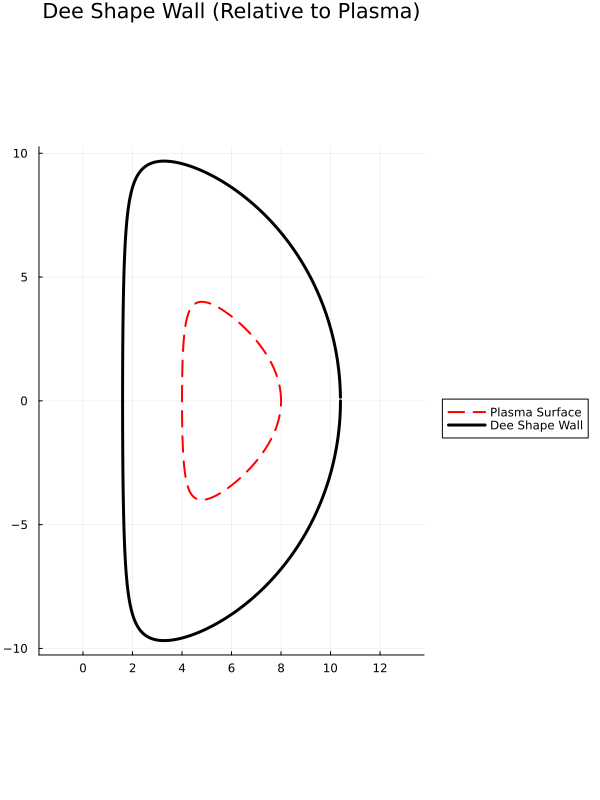

In [56]:
# 1. Settings for "dee" shape (Relative scaling)
shapings_dee = JPEC.VacuumMod.WallShapeSettings(
    shape = :dee,
    a = 1.2,    # Wall minor radius scale factor (1.2 times the plasma radius)
    bw = 2.2,   # Elongation (slightly longer than plasma's kappa=2.0)
    dw = 0.7,   # Triangularity (shaper D-shape than plasma's 0.6)
    tw = 0.1,   # Squareness (bulge at the 'shoulder' of the D-shape)
    cw = 0.0,   # Radial center offset relative to plasma center
    leqarcw = 1 # Arc-length re-parameterization flag (0: Off)
)

# Calculate wall coordinates
xwall_dee, zwall_dee, _ = JPEC.VacuumMod.wwall(inputs, shapings_dee, plasma)

# 2. Visualization
p_dee = plot(aspect_ratio=:equal, size=(600, 800), legend=:outerright)
plot!(p_dee, plasma.x, plasma.z, label="Plasma Surface", lw=2, color=:red, linestyle=:dash)
plot!(p_dee, xwall_dee, zwall_dee, label="Dee Shape Wall", lw=3, color=:black)
title!(p_dee, "Dee Shape Wall (Relative to Plasma)")
display(p_dee)

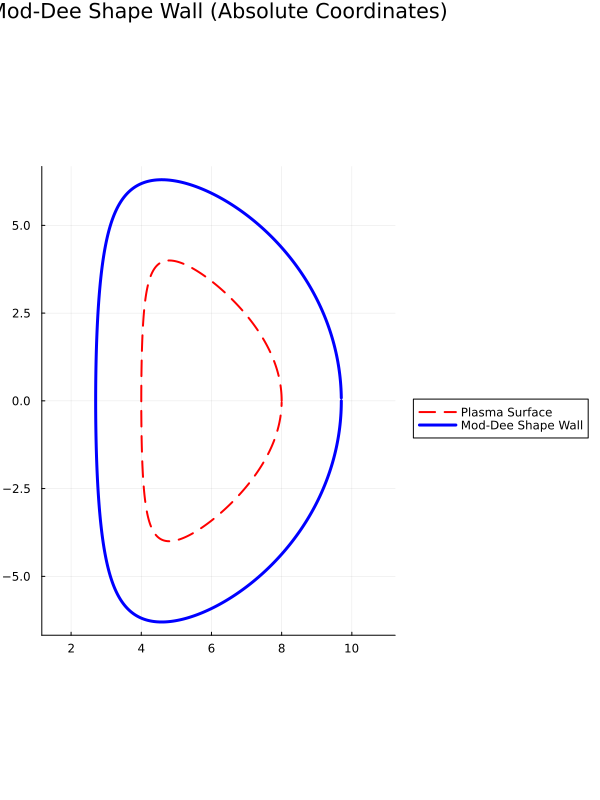

In [57]:
# 1. Settings for "mod_dee" shape (Absolute dimensions)
shapings_mod = JPEC.VacuumMod.WallShapeSettings(
    shape = :mod_dee,
    a = 3.5,    # Wall minor radius in absolute meters [m]
    bw = 1.8,   # Vertical elongation factor
    dw = 0.5,   # Triangularity factor (shaping the 'D')
    tw = 0.05,  # Squareness factor
    cw = 6.2,   # Absolute R-coordinate for the wall center [m]
    leqarcw = 0
)

# Calculate wall coordinates
xwall_mod, zwall_mod, _ = JPEC.VacuumMod.wwall(inputs, shapings_mod, plasma)

# 2. Visualization
p_mod = plot(aspect_ratio=:equal, size=(600, 800), legend=:outerright)
plot!(p_mod, plasma.x, plasma.z, label="Plasma Surface", lw=2, color=:red, linestyle=:dash)
plot!(p_mod, xwall_mod, zwall_mod, label="Mod-Dee Shape Wall", lw=3, color=:blue)
title!(p_mod, "Mod-Dee Shape Wall (Absolute Coordinates)")
display(p_mod)

# Elliptical

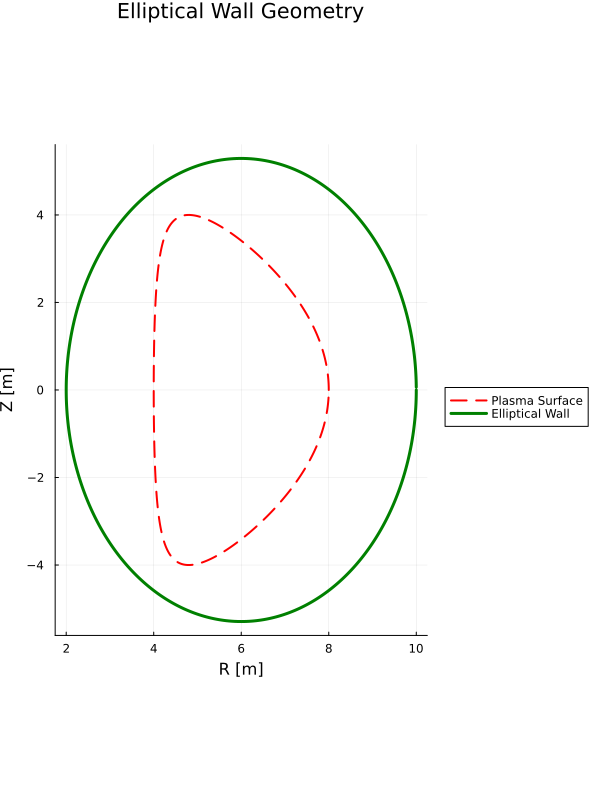

In [60]:
# 1. Settings for "elliptical" shape
# Note: For elliptical mode, 'a' is typically the absolute Major Radius of the wall.
# If plasma R0=6.0 and a=2.0, the plasma edge is at R=8.0. 
# So the wall 'a' should be > 8.0.
shapings_ell = JPEC.VacuumMod.WallShapeSettings(
    shape = :elliptical,
    a = 4.0,            # Absolute Major Radius of the wall [m]
    leqarcw = 1         # Arc-length re-parameterization flag
)

# Calculate wall coordinates
xwall_ell, zwall_ell, _ = JPEC.VacuumMod.wwall(inputs, shapings_ell, plasma)

# 2. Visualization
p_ell = plot(aspect_ratio=:equal, size=(600, 800), legend=:outerright)

# Plot Plasma Surface
plot!(p_ell, plasma.x, plasma.z, label="Plasma Surface", 
      lw=2, color=:red, linestyle=:dash)

# Plot Elliptical Wall
plot!(p_ell, xwall_ell, zwall_ell, label="Elliptical Wall", 
      lw=3, color=:green)

title!(p_ell, "Elliptical Wall Geometry")
xlabel!(p_ell, "R [m]")
ylabel!(p_ell, "Z [m]")

display(p_ell)

## from_file

In [61]:
# --- 1. Create a dummy "wall_geo.in" file ---
# In a real scenario, this file would come from CAD data or external diagnostic coordinates.
mtheta_val = 512
open("wall_geo.in", "w") do io
    println(io, mtheta_val)      # Row 1: Number of points (npots0)
    println(io, 6.2)             # Row 2: R-coordinate of the wall center (wcentr)
    println(io, "# index R Z")   # Row 3: Header/Comment line (skipped by the reader)
    
    # Generate a sample D-shaped wall boundary numerically
    for i in 1:mtheta_val
        # Calculate theta from 0 to 2π (Counter-Clockwise)
        theta = 2π * (i-1) / (mtheta_val-1)
        
        r = 6.2 + 3.0 * cos(theta + 0.3 * sin(theta))
        z = 4.5 * sin(theta)

        println(io, "$i  $r  $z")
    end
end

# --- 2. Configure Wall Settings ---

shapings = JPEC.VacuumMod.WallShapeSettings(
    shape = :from_file, 
    leqarcw = 1
)

JPEC.VacuumMod.WallShapeSettings(:from_file, 0.05, 1.5, 0.0, 0.5, 0.05, 1.2, 1.0, 0.0, 1, 500, 1.0e-5)

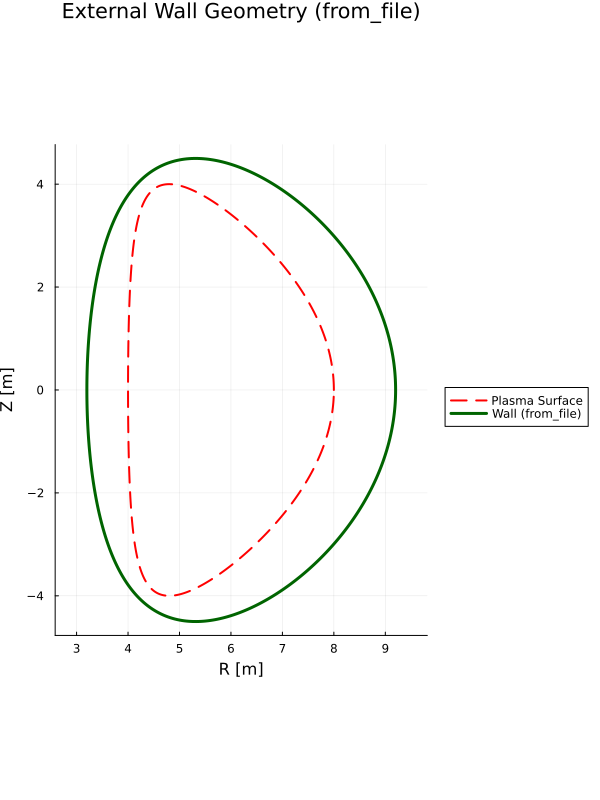

In [62]:
# --- 3. Call the wwall function ---
# Assumes 'inputs' and 'plasma' (PlasmaGeometry) objects are already defined in the workspace.
xwall, zwall, is_closed = JPEC.VacuumMod.wwall(inputs, shapings, plasma)

# --- 4. Visualization ---
p = plot(aspect_ratio=:equal, size=(600, 800), legend=:outerright)

# Plot the Plasma Boundary for reference
plot!(p, plasma.x, plasma.z, label="Plasma Surface", 
      lw=2, color=:red, linestyle=:dash)

# Plot the Vacuum Vessel Wall loaded from the file
plot!(p, xwall, zwall, label="Wall (from_file)", 
      lw=3, color=:darkgreen)

# Add plot labels and title
title!(p, "External Wall Geometry (from_file)")
xlabel!(p, "R [m]")
ylabel!(p, "Z [m]")

# Display the final plot
display(p)